C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset

Where the screenshots are located

In [181]:
import os
from pathlib import Path
from dotenv import load_dotenv
from huggingface_hub import login

# Load API keys from .env
dotenv_path = Path('.env') if Path('.env').exists() else Path('../.env')
load_dotenv(dotenv_path)

hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token, write_permission=False)
    print('✓ Successfully logged in to Hugging Face via .env')
else:
    print('⚠ HF_TOKEN not found in .env. Please define HF_TOKEN in your .env file.')


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to C:\Users\Aiden\.cache\huggingface\token
Login successful


In [29]:
#Model loading
from pathlib import Path
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

# 1. Configure model source
repo_id = "Ultralytics/YOLO11" # ONly matters for first time download
weight_file = "yolo11m-minimap.pt"

# 2. Save weights inside this project so future runs can load locally
model_dir = Path.cwd() / "models"
model_dir.mkdir(parents=True, exist_ok=True)
local_model_path = model_dir / weight_file

if local_model_path.exists():
    print(f"Using local model: {local_model_path}")
    model_path = local_model_path
else:
    print(f"Downloading {weight_file} to {model_dir}...")
    downloaded_path = hf_hub_download(
        repo_id=repo_id,
        filename=weight_file,
        local_dir=model_dir
    )
    model_path = Path(downloaded_path)
    print(f"Saved model to {model_path}")

# 3. Load local weights into Ultralytics
print(f"Loading weights from {model_path}...")
model = YOLO(str(model_path))

c:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using local model: c:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\pyLoL\models\yolo11m-minimap.pt
Loading weights from c:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\pyLoL\models\yolo11m-minimap.pt...


In [30]:
#Check CUDA Available
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

device = torch.cuda.get_device_name(0)

CUDA Available: True
Device Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [31]:
#Test inference
match_id = "SG2-171979173"
frame = 211
team = "Blue" #Blue/Red/All

import pandas as pd
from pathlib import Path
import re
import torch
from ultralytics import YOLO
from tqdm import tqdm

# 1. Setup
# model = YOLO("yolo11m.pt") 
folder_path = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\0\{team}"

def extract_frame_number(filepath):
    match = re.search(r'(\d+)\.png', str(filepath))
    return int(match.group(1)) if match else -1

image_paths = sorted(Path(folder_path).glob("*.png"), key=extract_frame_number)
image_paths_str = [str(p) for p in image_paths]

detection_data = []
print(f"Processing 1 frames in chunks on GPU...")

# batch=8 uses Tensor Cores efficiently. don't set imgsz=, already in 512x512 correct size) 
results = model(image_paths_str[frame], stream=True, batch=8,  conf=0.2, device=0, verbose=False)

for r in results:
    frame_number = extract_frame_number(r.path)
    
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        class_id = int(box.cls)
        conf = float(box.conf)
        champion_name = model.names[class_id]
        
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        
        detection_data.append({
            "frame": frame_number,
            "champion_id": class_id,
            "champion_name": champion_name,
            "x": round(center_x, 1),
            "y": round(center_y, 1),
            "confidence": round(conf, 3)
        })
    r.show()
    
    
print(detection_data)

Processing 1 frames in chunks on GPU...
[{'frame': 282, 'champion_id': 101, 'champion_name': 'Pyke', 'x': 391.2, 'y': 381.4, 'confidence': 0.944}, {'frame': 282, 'champion_id': 146, 'champion_name': 'Vayne', 'x': 69.9, 'y': 99.4, 'confidence': 0.912}, {'frame': 282, 'champion_id': 138, 'champion_name': 'Tristana', 'x': 402.8, 'y': 391.2, 'confidence': 0.908}, {'frame': 282, 'champion_id': 160, 'champion_name': 'Yone', 'x': 47.7, 'y': 112.6, 'confidence': 0.884}, {'frame': 282, 'champion_id': 81, 'champion_name': 'Mel', 'x': 276.4, 'y': 222.8, 'confidence': 0.878}, {'frame': 282, 'champion_id': 155, 'champion_name': 'Warwick', 'x': 91.3, 'y': 219.5, 'confidence': 0.84}, {'frame': 282, 'champion_id': 103, 'champion_name': 'Quinn', 'x': 119.0, 'y': 379.7, 'confidence': 0.835}]


# Data Obtaining (pass to Yolo model and get csv)

In [60]:
#PARAMS
match_id = "SG2-171524427"
chunk_size = 100 # Feeds the GPU exactly 200 images at a time
confidence = 0.2 # number between 0 and 1
batch_size = 8
team = "Blue" #Blue/Red/All

In [33]:
import pandas as pd
from pathlib import Path
import re
import torch
from ultralytics import YOLO
from tqdm import tqdm

# 1. Setup
# model = YOLO("yolo11m.pt") 
folder_path = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\0\{team}"

#Write an error/except here so that we dont go thru empty folder! (Wrong team)

def extract_frame_number(filepath):
    match = re.search(r'(\d+)\.png', str(filepath))
    return int(match.group(1)) if match else -1

image_paths = sorted(Path(folder_path).glob("*.png"), key=extract_frame_number)
image_paths_str = [str(p) for p in image_paths]

detection_data = []
print(f"Processing {len(image_paths_str)} frames in chunks on GPU...")

# We wrap the entire process in tqdm so you still get one smooth progress bar
with tqdm(total=len(image_paths_str), desc="Detecting Champions") as pbar:
    
    # 2. Slice the massive list into smaller chunks
    for i in range(0, len(image_paths_str), chunk_size):
        chunk = image_paths_str[i:i + chunk_size]
        
        # batch=8 uses Tensor Cores efficiently. don't set imgsz=, already in 512x512 correct size) 
        results = model(chunk, stream=True, batch=batch_size, conf=confidence, device=0, verbose=False)
        
        for r in results:
            frame_number = extract_frame_number(r.path)
            
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                class_id = int(box.cls)
                conf = float(box.conf)
                champion_name = model.names[class_id]
                
                center_x = (x1 + x2) / 2
                center_y = (y1 + y2) / 2
                
                detection_data.append({
                    "frame": frame_number,
                    "champion_id": class_id,
                    "champion_name": champion_name,
                    "x": round(center_x, 1),
                    "y": round(center_y, 1),
                    "confidence": round(conf, 3)
                })
            
            # Advance the progress bar by 1 frame
            pbar.update(1)

# 3. Save everything to CSV at the very end
df = pd.DataFrame(detection_data)
csv_output = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\{team} data\match_data.csv"

# This creates the \Blue folder (and any other missing parent folders) automatically!
Path(csv_output).parent.mkdir(parents=True, exist_ok=True)

df.to_csv(csv_output, index=False)

print(f"Done! Saved {len(df)} detections to {csv_output}")

Processing 1347 frames in chunks on GPU...


Detecting Champions:   0%|          | 0/1347 [00:00<?, ?it/s]

Detecting Champions: 100%|██████████| 1347/1347 [00:30<00:00, 43.99it/s]

Done! Saved 8623 detections to C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\SG2-171979173\Blue data\match_data.csv


# DATA CLEANING

In [34]:
import pandas as pd
from pathlib import Path
import re
import torch

In [35]:
#Load raw csv data
csv = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\{team} data\match_data.csv"

#load in csv from files at rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\{team} data\match_data.csv"

df = pd.read_csv(csv)

In [36]:
#Figure out how many, and where the gaps are
from pathlib import Path
import re

# Assuming folder_path is already defined, e.g.:
folder_path = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\0\{team}"

def extract_frame_number(filepath):
    match = re.search(r'(\d+)\.png', str(filepath))
    return int(match.group(1)) if match else -1

# 1. Grab all .png files and extract their frame numbers
image_paths = Path(folder_path).glob("*.png")
frames = [extract_frame_number(p) for p in image_paths]
# Filter out any that didn't match the regex
frames = [f for f in frames if f != -1]
frames.sort()

if not frames:
    print("No screenshots found.")
else:
    gaps = []
    total_missing = 0
    
    # 2. Iterate through the sorted frames and find jumps > 1
    for i in range(len(frames) - 1):
        diff = frames[i+1] - frames[i]
        if diff > 1:
            start_gap = frames[i] + 1
            end_gap = frames[i+1] - 1
            gaps.append((start_gap, end_gap))
            total_missing += diff - 1
            
    # 3. Print the results
    print(f"Total frames found: {len(frames)}")
    print(f"Total missing frames (gaps): {total_missing}\n")
    
    if total_missing > 0:
        print("Missing intervals (start -> end):")
        for start, end in gaps:
            if start == end:
                print(f" - Missing second: {start}")
            else:
                print(f" - Missing seconds: {start} to {end} ({end - start + 1} frames)")
    else:
        print("No gaps found! All screenshots are perfectly sequential.")


Total frames found: 1347
Total missing frames (gaps): 3

Missing intervals (start -> end):
 - Missing second: 980
 - Missing second: 1284
 - Missing second: 1385


### dedupe & Remove champions that weren't in game

In [37]:
# ---------------------------------------------------------
# STEP 1: Drop duplicates per frame
# ---------------------------------------------------------
# We sort by frame, then champion, then confidence (highest to lowest)
df = df.sort_values(by=['frame', 'champion_id', 'confidence'], ascending=[True, True, False])

# Now we drop duplicates, keeping the 'first' one (which is the highest confidence because of our sort)
df = df.drop_duplicates(subset=['frame', 'champion_id'], keep='first')

In [38]:
# ---------------------------------------------------------
# STEP 1.5: Purge base-structure hallucinations
# ---------------------------------------------------------
# Identify the hallucinated Tristana rows based on your exact parameters
# Blue base bottom-left corner (low X, high Y)
bad_tristana = (
    (df['champion_name'] == 'Tristana') & 
    (df['x'] < 70) & 
    (df['y'] > 440) | 
    (df['confidence'] < 0.6)
)

# Keep only the rows that are NOT the bad Tristanas
df = df[~bad_tristana]

# ---------------------------------------------------------
# STEP 2: Find the 10 most consistent champions
# ---------------------------------------------------------
champ_counts = df['champion_name'].value_counts()
print(champ_counts)

true_10_champs = champ_counts.nlargest(10).index.tolist()
print(f"\nThe true 10 champions for this match are: {true_10_champs}")

champion_name
Morgana    1124
Quinn      1045
Warwick    1019
Yone        928
Caitlyn     878
           ... 
Lulu          1
KSante        1
Hecarim       1
Ziggs         1
Ivern         1
Name: count, Length: 70, dtype: int64

The true 10 champions for this match are: ['Morgana', 'Quinn', 'Warwick', 'Yone', 'Caitlyn', 'Mel', 'Tristana', 'Vayne', 'Pyke', 'Volibear']


In [40]:
# ---------------------------------------------------------
# STEP 3: Purge the ghosts
# ---------------------------------------------------------
# Filter the dataframe to ONLY include those top 10 champions
df_clean = df[df['champion_name'].isin(true_10_champs)]

#### Fill in empty values

In [41]:
df = df_clean

In [42]:
df.set_index('champion_id')['champion_name'].to_dict()

{20: 'Caitlyn',
 81: 'Mel',
 103: 'Quinn',
 138: 'Tristana',
 146: 'Vayne',
 155: 'Warwick',
 86: 'Morgana',
 160: 'Yone',
 101: 'Pyke',
 154: 'Volibear'}

In [ ]:
# Fill in each frame such that if a champion is missing, let the positions be -1 for x and y, and 0 for confidence. 

import pandas as pd
import numpy as np

# 1. Isolate the true 10 champions (Assuming 'df' is already deduplicated)
true_champs = df['champion_id'].unique()

# 2. Define the absolute continuous timeline
# We use a range() so that if an ENTIRE frame was dropped, it still gets generated
all_frames = range(df['frame'].min(), df['frame'].max() + 1)

# 3. Create a perfect Cartesian grid of (Every Frame x Every Champion)
multi_idx = pd.MultiIndex.from_product(
    [all_frames, true_champs], 
    names=['frame', 'champion_id']
)

# 4. Reindex the DataFrame to this perfect grid
# This forces pandas to create the missing rows and fills them with NaNs
df_full = df.set_index(['frame', 'champion_id']).reindex(multi_idx).reset_index()

# 5. Fill the numerical holes
df_full['x'] = df_full['x'].fillna(-1)
df_full['y'] = df_full['y'].fillna(-1)
df_full['confidence'] = df_full['confidence'].fillna(0)

# 6. Restore the Champion Names (since they became NaN in the new rows)
# We create a dictionary mapping IDs to Names from the original data
champ_map = df.drop_duplicates('champion_id').set_index('champion_id')['champion_name'].to_dict()
df_full['champion_name'] = df_full['champion_id'].map(champ_map)

# Sort it chronologically so it's ready to be converted into a PyTorch tensor
df_full = df_full.sort_values(by=['frame', 'champion_id']).reset_index(drop=True)


|    |   frame |   champion_id | champion_name   |     x |     y |   confidence |
|---:|--------:|--------------:|:----------------|------:|------:|-------------:|
|  0 |      71 |            20 | Caitlyn         | 450.8 | 434.2 |        0.898 |
|  1 |      71 |            81 | Mel             | 274   | 241.1 |        0.91  |
|  2 |      71 |            86 | Morgana         |  -1   |  -1   |        0     |
|  3 |      71 |           101 | Pyke            |  -1   |  -1   |        0     |
|  4 |      71 |           103 | Quinn           | 249.5 | 274.9 |        0.892 |
|  5 |      71 |           138 | Tristana        | 436.8 | 399.6 |        0.893 |
|  6 |      71 |           146 | Vayne           |  71.1 |  73.8 |        0.909 |
|  7 |      71 |           154 | Volibear        |  -1   |  -1   |        0     |
|  8 |      71 |           155 | Warwick         | 251.4 | 129.6 |        0.755 |
|  9 |      71 |           160 | Yone            |  -1   |  -1   |        0     |
| 10 |      72 |

#### order by role [blue top, blue mid, blue jungle,... red supp,red bot]

In [44]:
# The highly rigid ADC roster
ADC_ROSTER = {
    'Aphelios', 'Ashe', 'Caitlyn', 'Draven', 'Ezreal', 'Jhin', 'Jinx', 
    'Kaisa', 'Kalista', 'KogMaw', 'Lucian', 'MissFortune', 'Nilah', 
    'Samira', 'Sivir', 'Smolder', 'Tristana', 'Twitch', 'Varus', 'Vayne', 'Xayah', 'Zeri',
    'Lux','Yasuo', 'Ziggs'
}

# The traditional support roster
SUPPORT_ROSTER = {
    'Alistar', 'Bard', 'Blitzcrank', 'Brand', 'Braum', 'Janna', 'Karma', 
    'Leona', 'Lulu', 'Milio', 'Morgana', 'Nami', 'Nautilus', 'Pyke', 
    'Rakan', 'Rell', 'Renata', 'Senna', 'Seraphine', 'Sona', 'Soraka', 
    'TahmKench', 'Taric', 'Thresh', 'Velkoz', 'Xerath', 'Yuumi', 'Zilean', 'Zyra','Camille'
}

In [45]:
import pandas as pd
import numpy as np

# Set a frame limit that corresponds to roughly the 10-14 minute mark of the match.
# (If your script captures ~1 frames per game-second, 10 minutes = ~600 frames)
early_game_limit = 600 

# 1. Filter out the missing rows AND isolate the laning phase
valid_positions = df_full[
    (df_full['x'] != -1) & 
    (df_full['frame'] <= early_game_limit)
]

# 2. Calculate the median AND variance for each champion using .agg()
roles_df = valid_positions.groupby(['champion_id', 'champion_name']).agg(
    median_x=('x', 'median'),
    median_y=('y', 'median'),
    var_x=('x', 'var'),
    var_y=('y', 'var')
).reset_index()

# Calculate the total spatial dispersion (Sum of X and Y variance)
roles_df['total_variance'] = roles_df['var_x'] + roles_df['var_y']

# 3. Apply the Spatial Metrics (Using the medians!)
# Negative = Blue territory, Positive = Red territory
roles_df['side_metric'] = roles_df['median_x'] - roles_df['median_y'] 
# Low = Top, High = Bot
roles_df['lane_metric'] = roles_df['median_x'] + roles_df['median_y'] 

# ============================================================
# STEP 3.5: Fountain-based team assignment
# ============================================================
FOUNTAIN_RADIUS = 70

blue_team_ids = set()
red_team_ids = set()

for champ_id in roles_df['champion_id'].values:
    champ_data = valid_positions[valid_positions['champion_id'] == champ_id]
    
    near_blue = ((champ_data['x'] < FOUNTAIN_RADIUS) & 
                 (champ_data['y'] > (512 - FOUNTAIN_RADIUS))).any()
    
    near_red  = ((champ_data['x'] > (512 - FOUNTAIN_RADIUS)) & 
                 (champ_data['y'] < FOUNTAIN_RADIUS)).any()
    
    if near_blue:
        blue_team_ids.add(champ_id)
    elif near_red:
        red_team_ids.add(champ_id)

# If we found 5 on one side, the rest are the other team
all_ids = set(roles_df['champion_id'].values)
if len(blue_team_ids) == 5:
    red_team_ids = all_ids - blue_team_ids
elif len(red_team_ids) == 5:
    blue_team_ids = all_ids - red_team_ids
else:
    # Fill in remaining unassigned champions
    unassigned = all_ids - blue_team_ids - red_team_ids
    for cid in unassigned:
        if len(blue_team_ids) < 5:
            blue_team_ids.add(cid)
        else:
            red_team_ids.add(cid)

roles_df['team'] = roles_df['champion_id'].apply(
    lambda x: 'Blue' if x in blue_team_ids else 'Red'
)

print(f"Blue: {[roles_df[roles_df['champion_id']==c]['champion_name'].iloc[0] for c in blue_team_ids]}")
print(f"Red:  {[roles_df[roles_df['champion_id']==c]['champion_name'].iloc[0] for c in red_team_ids]}")

# 6. Helper function to assign roles within a team
def assign_team_roles(team_df):
    # Sort by the lane metric (Top to Bot)
    team_df = team_df.sort_values('lane_metric').reset_index(drop=True)
    
    # Isolate the middle two players (Mid and Jungle)
    mid_jg = team_df.iloc[1:3].sort_values('total_variance')
    
    # The one with lower variance is Mid. The one with higher variance is Jungle.
    mid_idx = mid_jg.index[0]
    jg_idx = mid_jg.index[1]
    
    team_name = team_df['team'].iloc[0]
    roles = {}
    
    roles[team_df.loc[0, 'champion_id']] = f"{team_name}_Top"
    roles[team_df.loc[mid_idx, 'champion_id']] = f"{team_name}_Mid"
    roles[team_df.loc[jg_idx, 'champion_id']] = f"{team_name}_Jungle"
    
    # --- BOT / SUPPORT LOGIC REMAINS THE SAME ---
    bot_idx_1, bot_idx_2 = 3, 4
    champ_1_name = team_df.loc[bot_idx_1, 'champion_name']
    champ_1_id = team_df.loc[bot_idx_1, 'champion_id']
    
    champ_2_name = team_df.loc[bot_idx_2, 'champion_name']
    champ_2_id = team_df.loc[bot_idx_2, 'champion_id']
    
    # FILTER 1: Strict ADC Check
    if champ_1_name in ADC_ROSTER and champ_2_name not in ADC_ROSTER:
        roles[champ_1_id] = f"{team_name}_Bot"
        roles[champ_2_id] = f"{team_name}_Support"
    elif champ_2_name in ADC_ROSTER and champ_1_name not in ADC_ROSTER:
        roles[champ_2_id] = f"{team_name}_Bot"
        roles[champ_1_id] = f"{team_name}_Support"
        
    # FILTER 2: Support Check
    elif champ_1_name in SUPPORT_ROSTER and champ_2_name not in SUPPORT_ROSTER:
        roles[champ_1_id] = f"{team_name}_Support"
        roles[champ_2_id] = f"{team_name}_Bot"
    elif champ_2_name in SUPPORT_ROSTER and champ_1_name not in SUPPORT_ROSTER:
        roles[champ_2_id] = f"{team_name}_Support"
        roles[champ_1_id] = f"{team_name}_Bot"
        
    # FILTER 3: Fallback
    else:
        roles[champ_1_id] = f"{team_name}_Bot"
        roles[champ_2_id] = f"{team_name}_Support"
        
    team_df['role'] = team_df['champion_id'].map(roles)
    return team_df    

# 7. Apply to both teams
blue_team = assign_team_roles(roles_df[roles_df['team'] == 'Blue'])
red_team = assign_team_roles(roles_df[roles_df['team'] == 'Red'])

final_roles = pd.concat([blue_team, red_team])

# 8. Map the calculated roles back to your main DataFrame
role_mapping = final_roles.set_index('champion_id')['role'].to_dict()
df_full['role'] = df_full['champion_id'].map(role_mapping)

# 9. Force the DataFrame to sort identically every single frame
ordered_roles = [
    'Blue_Top', 'Blue_Jungle', 'Blue_Mid', 'Blue_Bot', 'Blue_Support',
    'Red_Top', 'Red_Jungle', 'Red_Mid', 'Red_Bot', 'Red_Support'
]

df_full['role'] = pd.Categorical(df_full['role'], categories=ordered_roles, ordered=True)
df_full = df_full.sort_values(['frame', 'role']).reset_index(drop=True)

print(df_full.head(10).to_markdown())

Blue: ['Yone', 'Quinn', 'Caitlyn', 'Morgana', 'Warwick']
Red:  ['Pyke', 'Tristana', 'Mel', 'Vayne', 'Volibear']
|    |   frame |   champion_id | champion_name   |     x |     y |   confidence | role         |
|---:|--------:|--------------:|:----------------|------:|------:|-------------:|:-------------|
|  0 |      71 |           160 | Yone            |  -1   |  -1   |        0     | Blue_Top     |
|  1 |      71 |           155 | Warwick         | 251.4 | 129.6 |        0.755 | Blue_Jungle  |
|  2 |      71 |           103 | Quinn           | 249.5 | 274.9 |        0.892 | Blue_Mid     |
|  3 |      71 |            20 | Caitlyn         | 450.8 | 434.2 |        0.898 | Blue_Bot     |
|  4 |      71 |            86 | Morgana         |  -1   |  -1   |        0     | Blue_Support |
|  5 |      71 |           146 | Vayne           |  71.1 |  73.8 |        0.909 | Red_Top      |
|  6 |      71 |           154 | Volibear        |  -1   |  -1   |        0     | Red_Jungle   |
|  7 |      71 

#### Save cleaned data

In [46]:
# Save cleaned data

csv_output = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\{team} data\cleaned_match_data.csv"

# This creates the \Blue folder (and any other missing parent folders) automatically!
Path(csv_output).parent.mkdir(parents=True, exist_ok=True)

df_full.to_csv(csv_output, index=False)

print(f"Done! Saved {len(df)} detections to {csv_output}")

Done! Saved 7536 detections to C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\SG2-171979173\Blue data\cleaned_match_data.csv


## Model Initialization

In [61]:
import pandas as pd
#Load cleaned csv data
csv_blue = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\Blue data\cleaned_match_data.csv"
csv_all = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\All data\cleaned_match_data.csv"

df_blue = pd.read_csv(csv_blue)
df_all = pd.read_csv(csv_all)

In [48]:
# Hyperparams
seq_len = 60 #Number of frames to accept

In [49]:
# Initialization

import torch
import torch.nn as nn
import torch.nn.functional as F

class FogOfWarTransformer(nn.Module):
    def __init__(self, num_roles=10, features_per_role=3, hidden_dim=128, nhead=4, num_layers=3, seq_len=seq_len):
        super().__init__()
        self.num_roles = num_roles
        
        # 10 roles * 3 features (X, Y, Visibility) = 30
        self.input_dim = num_roles * features_per_role 
        
        # 10 roles * 5 Gaussian parameters = 50
        self.output_dim = num_roles * 5 

        # 1. Input Embedding
        self.input_proj = nn.Linear(self.input_dim, hidden_dim)

        # 2. Positional Encoding (Learned parameter for a fixed sequence length)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, hidden_dim))

        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, 
            nhead=nhead, 
            dim_feedforward=hidden_dim * 4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4. Output Head
        self.output_head = nn.Linear(hidden_dim, self.output_dim)

    def forward(self, x):
        # Expected input shape: (Batch_Size, Seq_Len=10, Features=30)
        
        # Embed the inputs and add positional awareness
        x = self.input_proj(x) + self.pos_encoder
        
        # Pass through the self-attention blocks
        x = self.transformer(x)
        
        # We extract only the network's state at the FINAL time step to predict the future
        last_frame_hidden = x[:, -1, :] # Shape: (Batch, Hidden_Dim)
        
        # Predict the raw Gaussian parameters
        raw_out = self.output_head(last_frame_hidden) # Shape: (Batch, 50)
        
        # Reshape to group the 5 parameters by role: (Batch, 10, 5)
        out = raw_out.view(-1, self.num_roles, 5)
        
        # Isolate the parameters
        mu_x = out[:, :, 0]
        mu_y = out[:, :, 1]
        sigma_x = out[:, :, 2]
        sigma_y = out[:, :, 3]
        rho = out[:, :, 4]
        
        # --- MATHEMATICAL BOUNDS ---
        # Sigmas must be strictly positive. Softplus gently curves negative numbers to near-zero.
        # We add 1e-5 to prevent division-by-zero crashes during loss calculation.
        sigma_x = F.softplus(sigma_x) + 1e-5 
        sigma_y = F.softplus(sigma_y) + 1e-5
        
        # Rho (correlation) must be bounded between -1 and 1
        rho = torch.tanh(rho)
        
        # Recombine and return the bounded parameters
        return torch.stack([mu_x, mu_y, sigma_x, sigma_y, rho], dim=-1)

In [ ]:
# Initialize the model or load from local

import os
from pathlib import Path
import torch

model = FogOfWarTransformer(num_roles=10, features_per_role=3, hidden_dim=128, nhead=4, num_layers=3, seq_len=seq_len)

# Check for saved checkpoint
checkpoint_paths = ["fow_transformer_match.pt"]
loaded = False

for checkpoint_path in checkpoint_paths:
    if os.path.exists(checkpoint_path):
        state_dict = torch.load(checkpoint_path, map_location="cpu")
        model.load_state_dict(state_dict)
        print(f"Loaded existing model weights from '{checkpoint_path}'!")
        loaded = True
        break

if not loaded:
    print("No local checkpoint found ('fow_transformer.pt' / 'fow_transformer_match.pt'). Initialized fresh weights.")

# Print the architecture
print(model)

# Calculate the total number of learnable parameters (weights and biases)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal learnable parameters: {total_params:,}")


C:\Users\Aiden\AppData\Local\Temp\ipykernel_30368\544791439.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location="cpu")

Loaded existing model weights from 'fow_transformer_match.pt'!
FogOfWarTransformer(
  (input_proj): Linear(in_features=30, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_head): Linear(in_features=128, out_features=50, bias=True)
)

Total learnable parameters: 612,914


### Data loading

In [62]:
# Data loader
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

class LeagueTrajectoryDataset(Dataset):
    def __init__(self, df_input, df_target, seq_len=60, map_size=512.0):
        self.seq_len = seq_len
        self.map_size = map_size
        
        # 1. Pivot the Input Data (Blue Side Vision)
        pivot_in = df_input.pivot(index='frame', columns='role', values=['x', 'y', 'confidence'])

        # 2. Pivot the Target Data (Ground Truth)
        pivot_targ = df_target.pivot(index='frame', columns='role', values=['x', 'y'])

        # Force pivot columns to follow ordered_roles instead of alphabetical
        ordered_roles = [
            'Blue_Top', 'Blue_Jungle', 'Blue_Mid', 'Blue_Bot', 'Blue_Support',
            'Red_Top', 'Red_Jungle', 'Red_Mid', 'Red_Bot', 'Red_Support'
        ]
        pivot_in = pivot_in.reindex(columns=pd.MultiIndex.from_product(
            [['x', 'y', 'confidence'], ordered_roles]
        ))
        pivot_targ = pivot_targ.reindex(columns=pd.MultiIndex.from_product(
            [['x', 'y'], ordered_roles]
        ))

        # 3. Make sure frames align
        common_frames = pivot_in.index.intersection(pivot_targ.index)
        pivot_in = pivot_in.loc[common_frames]
        pivot_targ = pivot_targ.loc[common_frames]
        self.frame_ids = list(common_frames)
        
        # 4. Reshape Target to (Num_Frames, 10, 2)
        target_tensors = []
        for role in ordered_roles:
            x_col = pivot_targ['x'][role].values
            y_col = pivot_targ['y'][role].values
            role_tensor = np.stack([x_col, y_col], axis=-1) # Shape: (Frames, 2)
            target_tensors.append(role_tensor)
            
        in_values = torch.tensor(pivot_in.values, dtype=torch.float32)
        targ_values = torch.tensor(np.stack(target_tensors, axis=1), dtype=torch.float32)

        # 5. Normalize coordinates to [0, 1] while preserving -1 for missing values
        # in_values has 30 features: 10 x's, 10 y's, 10 confidences (0..19 are coords)
        in_coords = in_values[:, :20]
        in_values[:, :20] = torch.where(in_coords >= 0, in_coords / self.map_size, in_coords)

        # targ_values has shape (Frames, 10, 2)
        targ_values = torch.where(targ_values >= 0, targ_values / self.map_size, targ_values)

        self.input_data = in_values
        self.target_data = targ_values

    def __len__(self):
        return len(self.input_data) - self.seq_len

    def __getitem__(self, idx):
        x = self.input_data[idx : idx + self.seq_len]
        y = self.target_data[idx + self.seq_len]
        return x, y

# --- Instantiate the Dataset and DataLoader ---
dataset = LeagueTrajectoryDataset(df_blue, df_all, seq_len=seq_len)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test it out to see the shapes and normalized ranges!
x_batch, y_batch = next(iter(dataloader))
print(f"Input batch shape: {x_batch.shape}")   # Expected: [32, seq_len, 30]
print(f"Target batch shape: {y_batch.shape}")  # Expected: [32, 10, 2]
print(f"Total aligned frames available: {len(dataset.frame_ids)}")


Input batch shape: torch.Size([32, 60, 30])
Target batch shape: torch.Size([32, 10, 2])
Total aligned frames available: 1428


In [63]:
print(x_batch[0,59],'\n',y_batch[0])

tensor([ 0.1088, -1.0000,  0.4418,  0.8801, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,  0.8824,  0.2271, -1.0000,  0.5533,  0.7453, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,  0.5818,  0.8890,  0.0000,  0.8920,  0.8980,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.8870]) 
 tensor([[ 0.1084,  0.2330],
        [-1.0000, -1.0000],
        [ 0.4633,  0.5330],
        [ 0.8738,  0.7238],
        [-1.0000, -1.0000],
        [-1.0000, -1.0000],
        [-1.0000, -1.0000],
        [-1.0000, -1.0000],
        [ 0.9453,  0.1102],
        [ 0.8576,  0.5971]])


In [54]:
# Do dry forward pass of the model to see if it works
import torch

# 1. Grab a single batch of data from the dataloader
x_batch, y_batch = next(iter(dataloader))

print("--- RAW TENSOR SHAPES ---")
print(f"Input x_batch:  {x_batch.shape}")   # Expected: [32, seq_len, 30]
print(f"Target y_batch: {y_batch.shape}")   # Expected: [32, 10, 2]

# 2. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

# 3. Execute the Forward Pass in eval mode (disables dropout for deterministic output)
model.eval()
with torch.no_grad():
    predictions = model(x_batch)

print("\n--- FORWARD PASS SUCCESS ---")
print(f"Model Output:   {predictions.shape}") # Expected: [32, 10, 5]

# 4. Inspect the math for a single role (Batch 0, Blue_Top)
print("\n--- SAMPLE GAUSSIAN OUTPUT (Batch 0, Blue_Top) ---")
sample_pred = predictions[0, 0]

mu_x  = sample_pred[0].item()
mu_y  = sample_pred[1].item()
sig_x = sample_pred[2].item()
sig_y = sample_pred[3].item()
rho   = sample_pred[4].item()

print(f"Normalized Mean X (μ_x):       {mu_x:.4f}  -> Pixel: {mu_x * 512.0:.1f}")
print(f"Normalized Mean Y (μ_y):       {mu_y:.4f}  -> Pixel: {mu_y * 512.0:.1f}")
print(f"Variance X (σ_x):              {sig_x:.4f} (Must be > 0)")
print(f"Variance Y (σ_y):              {sig_y:.4f} (Must be > 0)")
print(f"Correlation (ρ):               {rho:.4f} (Must be between -1 and 1)")


--- RAW TENSOR SHAPES ---
Input x_batch:  torch.Size([32, 60, 30])
Target y_batch: torch.Size([32, 10, 2])

--- FORWARD PASS SUCCESS ---
Model Output:   torch.Size([32, 10, 5])

--- SAMPLE GAUSSIAN OUTPUT (Batch 0, Blue_Top) ---
Normalized Mean X (μ_x):       0.2247  -> Pixel: 115.1
Normalized Mean Y (μ_y):       0.3593  -> Pixel: 183.9
Variance X (σ_x):              0.0217 (Must be > 0)
Variance Y (σ_y):              0.0596 (Must be > 0)
Correlation (ρ):               -0.2659 (Must be between -1 and 1)


# Model Training

Training on Device: cuda | Total Samples in Match: 1290 | Batches per Epoch: 40

Epoch        | Avg Loss       | Avg Sigma (px)     | LR        
Epoch 001/040   | -1.1835        | 243.28             | 0.00200   
Epoch 005/040   | -3.3623        | 63.52              | 0.00193   
Epoch 010/040   | -4.3019        | 40.49              | 0.00172   
Epoch 015/040   | -4.8795        | 30.77              | 0.00141   
Epoch 020/040   | -5.2791        | 25.58              | 0.00105   
Epoch 025/040   | -5.6146        | 22.04              | 0.00069   
Epoch 030/040   | -5.8738        | 19.50              | 0.00038   
Epoch 035/040   | -6.0900        | 17.49              | 0.00017   
Epoch 040/040   | -6.2191        | 16.48              | 0.00010   
Training completed in 31.4s!
Saved model checkpoint to 'fow_transformer_match.pt'


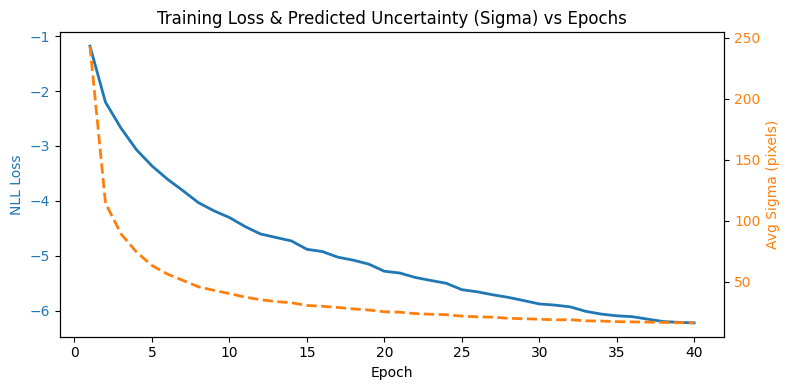

In [58]:
# --- FULL MATCH TRAINING LOOP ---
# Train on the entire single match (df_blue -> df_all) across multiple epochs

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

# 1. Define Loss Function
def bivariate_gaussian_nll_loss(predictions, targets, mask=None):
    """
    predictions: Tensor of shape (Batch, 10, 5) -> [mu_x, mu_y, sigma_x, sigma_y, rho]
    targets:     Tensor of shape (Batch, 10, 2) -> [x_gt, y_gt]
    mask:        Boolean tensor of shape (Batch, 10), True for valid positions
    """
    mu_x    = predictions[..., 0]
    mu_y    = predictions[..., 1]
    sigma_x = torch.clamp(predictions[..., 2], min=1e-4, max=10.0)
    sigma_y = torch.clamp(predictions[..., 3], min=1e-4, max=10.0)
    rho     = predictions[..., 4]

    x_gt = targets[..., 0]
    y_gt = targets[..., 1]

    # Standardized deviations
    z_x = (x_gt - mu_x) / sigma_x
    z_y = (y_gt - mu_y) / sigma_y

    # Clamp correlation (rho) slightly to avoid log(0) or division by 0
    rho = torch.clamp(rho, -0.999, 0.999)
    one_minus_rho2 = 1.0 - (rho ** 2)

    # Mahalanobis distance exponent term (Z)
    Z = (z_x ** 2 + z_y ** 2 - 2 * rho * z_x * z_y) / one_minus_rho2

    # Negative Log-Likelihood formula for 2D Gaussian
    nll = torch.log(sigma_x) + torch.log(sigma_y) + 0.5 * torch.log(one_minus_rho2) + 0.5 * Z

    # Ignore unobserved/missing champions (-1 coordinates)
    if mask is not None:
        nll = nll[mask]

    return nll.mean()

# 2. Prepare Dataset and DataLoader for the match
dataset = LeagueTrajectoryDataset(df_blue, df_all, seq_len=seq_len)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on Device: {device} | Total Samples in Match: {len(dataset)} | Batches per Epoch: {len(dataloader)}")

# 3. Re-initialize Model, Optimizer, and LR Scheduler
model = FogOfWarTransformer(num_roles=10, features_per_role=3, hidden_dim=128, nhead=4, num_layers=3, seq_len=seq_len).to(device)

num_epochs = 40
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)

# 4. Training Loop
loss_history = []
sigma_history = []

start_time = time.time()
print("\n" + "="*65)
print(f"{'Epoch':<12} | {'Avg Loss':<14} | {'Avg Sigma (px)':<18} | {'LR':<10}")
print("="*65)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_sigma = 0.0
    total_batches = 0
    
    for x_b, y_b in dataloader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)
        
        valid_mask = (y_b[:, :, 0] >= 0)
        
        optimizer.zero_grad()
        predictions = model(x_b)
        
        loss = bivariate_gaussian_nll_loss(predictions, y_b, mask=valid_mask)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        running_sigma += predictions[:, :, 2:4].mean().item() * 512.0
        total_batches += 1
        
    scheduler.step()
    
    epoch_loss = running_loss / total_batches
    epoch_sigma = running_sigma / total_batches
    current_lr = scheduler.get_last_lr()[0]
    
    loss_history.append(epoch_loss)
    sigma_history.append(epoch_sigma)
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch+1:03d}/{num_epochs:03d}   | {epoch_loss:<14.4f} | {epoch_sigma:<18.2f} | {current_lr:<10.5f}")

elapsed = time.time() - start_time
print("="*65)
print(f"Training completed in {elapsed:.1f}s!")

# 5. Save Model Weights
torch.save(model.state_dict(), "fow_transformer_match.pt")
print("Saved model checkpoint to 'fow_transformer_match.pt'")

# 6. Plot Loss & Uncertainty Curve
fig, ax1 = plt.subplots(figsize=(8, 4))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('NLL Loss', color=color)
ax1.plot(range(1, num_epochs + 1), loss_history, color=color, linewidth=2, label='Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Avg Sigma (pixels)', color=color)
ax2.plot(range(1, num_epochs + 1), sigma_history, color=color, linestyle='--', linewidth=2, label='Sigma')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Loss & Predicted Uncertainty (Sigma) vs Epochs')
fig.tight_layout()
plt.show()


In [65]:
match_id="SG2-171979173"

In [66]:
# --- MINIMAP PREDICTION OVERLAY VISUALIZER ---
# Visualizes model predictions & Gaussian uncertainty heatmaps directly over Blue-side screenshots

import cv2
import torch
import numpy as np
from pathlib import Path

# 1. Configuration
screenshots_dir = Path(rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\0\Blue")
save_video_path = rf"C:\Users\Aiden\Coding\python_ws\LeagueMapPredictor\Dataset\{match_id}\overlay_visualization.mp4"

# Set model to evaluation mode
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

ROLE_NAMES = [
    'Blue_Top', 'Blue_Jungle', 'Blue_Mid', 'Blue_Bot', 'Blue_Support',
    'Red_Top', 'Red_Jungle', 'Red_Mid', 'Red_Bot', 'Red_Support'
]

ROLE_TAGS = ['B-Top', 'B-Jg', 'B-Mid', 'B-Bot', 'B-Sup', 'R-Top', 'R-Jg', 'R-Mid', 'R-Bot', 'R-Sup']

# Colors in BGR format
COLOR_BLUE = (255, 180, 50)   # Sky Blue / Cyan
COLOR_RED = (50, 60, 240)     # Bright Red
COLOR_GT = (50, 255, 120)     # Lime Green (Ground Truth)

def draw_gaussian_ellipse(overlay, center, sig_x, sig_y, rho, color, n_std=2.0):
    """Draws a 2-sigma confidence ellipse representing the Gaussian uncertainty."""
    # 2x2 covariance matrix
    cov = np.array([
        [sig_x**2, rho * sig_x * sig_y],
        [rho * sig_x * sig_y, sig_y**2]
    ], dtype=np.float32)
    
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    order = eigenvals.argsort()[::-1]
    eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]
    
    # Major and minor axis lengths (2-sigma encompasses ~86-95% probability)
    axis_major = max(int(n_std * np.sqrt(max(eigenvals[0], 1e-4))), 3)
    axis_minor = max(int(n_std * np.sqrt(max(eigenvals[1], 1e-4))), 3)
    
    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    
    # Draw semi-transparent filled ellipse
    cv2.ellipse(overlay, (int(center[0]), int(center[1])), (axis_major, axis_minor),
                angle, 0, 360, color, -1)

print(f"Total testable frames in match: {len(dataset)}")
print("Launching Interactive Overlay Viewer...")
print("Controls: [Space] Pause/Play | [A/D] Step Frame | [G] Toggle Ground Truth | [+/-] Speed | [Q] Quit")

# 2. Interactive OpenCV Playback Loop
cv2.namedWindow('League Fog of War Predictor - Blue POV Overlay', cv2.WINDOW_NORMAL)
cv2.resizeWindow('League Fog of War Predictor - Blue POV Overlay', 768, 768)

current_idx = 0
paused = False
show_ground_truth = True
delay_ms = 40  # ~25 FPS

# Optional: Video Writer (set to True if you wish to export an MP4)
SAVE_TO_VIDEO = False
video_writer = None
if SAVE_TO_VIDEO:
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(save_video_path, fourcc, 25.0, (512, 512))
    print(f"Recording video to {save_video_path}...")

while current_idx < len(dataset):
    # A. Load Screenshot
    target_frame_num = dataset.frame_ids[current_idx + seq_len]
    img_path = screenshots_dir / f"{target_frame_num}.png"
    
    if img_path.exists():
        frame = cv2.imread(str(img_path))
        if frame.shape[:2] != (512, 512):
            frame = cv2.resize(frame, (512, 512))
    else:
        frame = np.zeros((512, 512, 3), dtype=np.uint8)

    overlay = frame.copy()

    # B. Run Model Inference on the 60-frame history window
    x_sample, y_sample = dataset[current_idx]
    x_in = x_sample.unsqueeze(0).to(device)
    
    with torch.no_grad():
        preds = model(x_in)[0].cpu() # Shape: (10, 5)

    MAP_SIZE = 512.0

    # C. Draw Gaussian Heatmaps / Uncertainty Ellipses for Red Team First (in background)
    for r_idx in range(5, 10):  # Roles 5..9 are Red Team
        mu_x = preds[r_idx, 0].item() * MAP_SIZE
        mu_y = preds[r_idx, 1].item() * MAP_SIZE
        sig_x = preds[r_idx, 2].item() * MAP_SIZE
        sig_y = preds[r_idx, 3].item() * MAP_SIZE
        rho = preds[r_idx, 4].item()
        
        # Clamp center to canvas
        mu_x = np.clip(mu_x, 0, 511)
        mu_y = np.clip(mu_y, 0, 511)
        
        draw_gaussian_ellipse(overlay, (mu_x, mu_y), sig_x, sig_y, rho, COLOR_RED, n_std=2.0)

    # Blend the uncertainty ellipses onto the screenshot
    cv2.addWeighted(overlay, 0.35, frame, 0.65, 0, frame)

    # D. Draw Crisp Center Markers & Labels on Top
    for r_idx in range(10):
        is_red = (r_idx >= 5)
        color = COLOR_RED if is_red else COLOR_BLUE
        tag = ROLE_TAGS[r_idx]
        
        mu_x = int(np.clip(preds[r_idx, 0].item() * MAP_SIZE, 0, 511))
        mu_y = int(np.clip(preds[r_idx, 1].item() * MAP_SIZE, 0, 511))
        sig_avg = (preds[r_idx, 2].item() + preds[r_idx, 3].item()) * 0.5 * MAP_SIZE

        # Ground Truth Marker (if enabled and observed)
        if show_ground_truth:
            gt_norm = y_sample[r_idx]
            if gt_norm[0] >= 0:
                gt_x = int(gt_norm[0].item() * MAP_SIZE)
                gt_y = int(gt_norm[1].item() * MAP_SIZE)
                # Small crosshair / target circle
                cv2.circle(frame, (gt_x, gt_y), 4, COLOR_GT, 1)
                cv2.drawMarker(frame, (gt_x, gt_y), COLOR_GT, markerType=cv2.MARKER_CROSS, markerSize=8, thickness=1)

        # Predicted Center Point
        cv2.circle(frame, (mu_x, mu_y), 5, (0, 0, 0), -1)        # Black shadow
        cv2.circle(frame, (mu_x, mu_y), 4, color, -1)            # Team color
        cv2.circle(frame, (mu_x, mu_y), 4, (255, 255, 255), 1)   # White outline

        # Role Tag
        label = f"{tag}"
        cv2.putText(frame, label, (mu_x + 6, mu_y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 0, 0), 2)
        cv2.putText(frame, label, (mu_x + 6, mu_y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1)

    # E. Render Top HUD Bar
    hud_bg = frame[:38, :].copy()
    cv2.rectangle(frame, (0, 0), (512, 38), (20, 20, 20), -1)
    cv2.addWeighted(hud_bg, 0.4, frame[:38, :], 0.6, 0, frame[:38, :])
    
    status_text = "[PAUSED]" if paused else f"[{int(1000/delay_ms)} FPS]"
    hud_info = f"Frame: {target_frame_num} ({current_idx+1}/{len(dataset)})  {status_text}"
    cv2.putText(frame, hud_info, (10, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

    gt_info = f"GT Overlay: {'ON (Green)' if show_ground_truth else 'OFF'}  |  [G] Toggle"
    cv2.putText(frame, gt_info, (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.35, COLOR_GT if show_ground_truth else (150, 150, 150), 1)

    if video_writer is not None:
        video_writer.write(frame)

    cv2.imshow('League Fog of War Predictor - Blue POV Overlay', frame)

    # F. Interactive Keyboard Controls
    key = cv2.waitKey(0 if paused else delay_ms) & 0xFF
    
    if key == ord('q') or key == 27:  # Q or Esc to quit
        break
    elif key == ord(' '):  # Spacebar to pause / unpause
        paused = not paused
    elif key == ord('d') or key == 83:  # D or Right Arrow: Next Frame
        current_idx = min(current_idx + 1, len(dataset) - 1)
    elif key == ord('a') or key == 81:  # A or Left Arrow: Prev Frame
        current_idx = max(current_idx - 1, 0)
    elif key == ord('g'):  # G: Toggle Ground Truth
        show_ground_truth = not show_ground_truth
    elif key == ord('+') or key == ord('='):  # Faster
        delay_ms = max(5, delay_ms - 10)
    elif key == ord('-') or key == ord('_'):  # Slower
        delay_ms = min(200, delay_ms + 10)
    else:
        if not paused:
            current_idx += 1

if video_writer is not None:
    video_writer.release()
    print(f"Video saved successfully to {save_video_path}")

cv2.destroyAllWindows()
print("Viewer closed.")


Total testable frames in match: 1368
Launching Interactive Overlay Viewer...
Controls: [Space] Pause/Play | [A/D] Step Frame | [G] Toggle Ground Truth | [+/-] Speed | [Q] Quit
Viewer closed.


### Bypass pyLol's screenshotting and directly use OBS virtual camera for live capture

In [3]:
import winsound

# Format: winsound.Beep(frequency_hz, duration_ms)
#winsound.Beep(2000, 700)  # Plays a 440Hz tone (A4) for half a second


In [6]:
import cv2
from ultralytics import YOLO

# Remove CAP_DSHOW. Let Windows use its default Media Foundation backend.
# Try 0, 1, 2, or 3 until it grabs the OBS feed.
cap = cv2.VideoCapture(2) 

if not cap.isOpened():
    print("Cannot open camera.")
    exit()

print("Connected to OBS Virtual Camera. Press 'q' to quit.")
num_detections = 0
while True:
    ret, frame = cap.read()
    
    if not ret or frame is None:
        continue
        
    h, w = frame.shape[:2]
    
    # Dynamically slice the bottom-right corner based on whatever resolution OpenCV negotiated
    minimap_cropped = frame[int(h * 0.5):h, int(w * 0.7):w]
    
    if minimap_cropped.size == 0:
        continue
        
    if minimap_cropped.shape[:2] != (512, 512):
        minimap_512 = cv2.resize(minimap_cropped, (512, 512), interpolation=cv2.INTER_CUBIC)
    else:
        minimap_512 = minimap_cropped
        
    # Run YOLO
    results = model(minimap_512, conf=0.8, verbose=False)
    #for r in results:
        #if num_detections < len(r.boxes):
           # winsound.Beep(2000, 700)  # Plays a 440Hz tone (A4) for half a second
    #num_detections = len(r.boxes)

    #Display 
    annotated = results[0].plot()
    cv2.imshow('Live Minimap Tracking (Virtual Cam)', annotated)
    
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Connected to OBS Virtual Camera. Press 'q' to quit.


Side: PW pose estimation

In [ ]:
import cv2
import time
import winsound
from ultralytics import YOLO

# 1. Load the Pose model
#model = YOLO("yolo11n-pose.pt")

cv2.namedWindow('Live Fall Detection', cv2.WINDOW_NORMAL)
cap = cv2.VideoCapture(2) 

if not cap.isOpened():
    print("Cannot open camera.")
    exit()

print("Connected to OBS Virtual Camera. Press 'q' to quit.")

# --- Fall Tracking Dictionary ---
# Instead of one timer, we use a dictionary to track multiple people.
# Format: {track_id: fall_start_time}
fall_timers = {}
FALL_THRESHOLD = 3.0

while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        continue
        
    # 2. Use .track() instead of calling the model directly!
    # persist=True tells YOLO to remember objects across frames.
    results = model.track(frame, conf=0.6, persist=True, verbose=False)
    annotated = results[0].plot()
    
    # Ensure there is actually a person detected AND they have been assigned an ID
    if results[0].boxes is not None and results[0].boxes.id is not None:
        
        # Extract the bounding boxes and their unique tracking IDs
        boxes = results[0].boxes.xyxy.tolist()
        track_ids = results[0].boxes.id.int().tolist()
        
        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box
            width = x2 - x1
            height = y2 - y1
            
            # 3. Posture Logic
            is_horizontal = width > (height * 1.2)
            
            # Explicitly require them to be noticeably taller than they are wide to count as standing
            is_vertical = height > (width * 1.2) 

            # 4. The Sticky Timer State Machine
            if is_horizontal:
                # If they just fell down, add them to our dictionary and start their clock
                if track_id not in fall_timers:
                    fall_timers[track_id] = time.time()
                    print(f"Person {track_id} went horizontal...")
                    
                # If they are already in the dictionary, check how long they have been down
                elif time.time() - fall_timers[track_id] >= FALL_THRESHOLD:
                    print(f"🚨 FALL DETECTED FOR PERSON {track_id}! 🚨")
                    winsound.Beep(1000, 500)
                    
                    # Reset their specific clock so it doesn't beep 30 times a second
                    fall_timers[track_id] = time.time() 
                    
            # YOUR LOGIC: Only delete their timer if we explicitly see them standing vertically again!
            elif is_vertical and track_id in fall_timers:
                print(f"Person {track_id} stood back up! Canceling alarm.")
                del fall_timers[track_id]

    cv2.imshow('Live Fall Detection', annotated)
    
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Connected to OBS Virtual Camera. Press 'q' to quit.
Person 1 went horizontal...
Person 1 stood back up! Canceling alarm.
Person 2 went horizontal...
Person 2 stood back up! Canceling alarm.
Person 2 went horizontal...
🚨 FALL DETECTED FOR PERSON 2! 🚨
Person 2 stood back up! Canceling alarm.
Person 2 went horizontal...
🚨 FALL DETECTED FOR PERSON 2! 🚨
